# Notebook 7: Decision Trees – Understanding Splits, Pruning & Overfitting
Part 7/30 – ML Mastery Series for Python Experts

## Why Decision Trees Are Intuitive Yet Dangerous

Decision trees are the gateway drug to ensemble methods, but they come with sharp edges:

- **White-box interpretability**: You can literally trace the exact path a prediction took through the tree
- **Handle mixed data types naturally**: No need to one-hot encode categoricals or scale numerics
- **Capture non-linear patterns**: Axis-aligned splits can approximate complex decision boundaries
- **No feature scaling needed**: Splits are based on ordering, not magnitude
- **But: extreme overfitting tendency**: Unrestricted trees memorize training data perfectly
- **High variance**: Small data changes → completely different tree structures
- **Axis-aligned limitation**: Diagonal boundaries require many small, jagged splits
- **Greedy algorithm**: Each split is locally optimal, not globally optimal

## Learning Objectives

By the end of this notebook, you will:

- Understand the mathematical difference between Gini impurity and entropy as split criteria
- Navigate the internal `.tree_` attributes to inspect node structures programmatically
- Visualize complete tree structures and interpret node statistics
- Demonstrate how unrestricted trees overfit and why this happens geometrically
- Control complexity using `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`
- Apply cost-complexity pruning (CCP) to find optimally pruned trees
- Compare classification and regression tree behaviors
- Develop intuition for when trees fail and why ensembles became necessary

## 🌳 1. Building a Basic Classification Tree – Iris Dataset

Let's start with the classic Iris dataset. We'll train an unrestricted tree and observe the classic overfitting signature: perfect training accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

# Set plotting style
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the classic Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {class_names}")

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [2]:
# Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train an unrestricted tree (default parameters)
# max_depth=None means nodes expand until leaves are pure
dt_unrestricted = DecisionTreeClassifier(random_state=42)
dt_unrestricted.fit(X_train, y_train)

# Predictions
y_train_pred = dt_unrestricted.predict(X_train)
y_test_pred = dt_unrestricted.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Tree depth: {dt_unrestricted.get_depth()}")
print(f"Number of leaves: {dt_unrestricted.get_n_leaves()}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Overfitting gap: {train_acc - test_acc:.4f}")

Tree depth: 5
Number of leaves: 8
Train accuracy: 1.0000
Test accuracy: 0.9333
Overfitting gap: 0.0667


Notice the pattern? **100% training accuracy** with a tree depth of 4-5. The model has memorized the training data. On Iris this is harmless (small dataset, clean boundaries), but on noisy data this is catastrophic.

## 🔍 2. Visualizing the Tree Structure

Let's open the black box and see exactly how decisions are made.

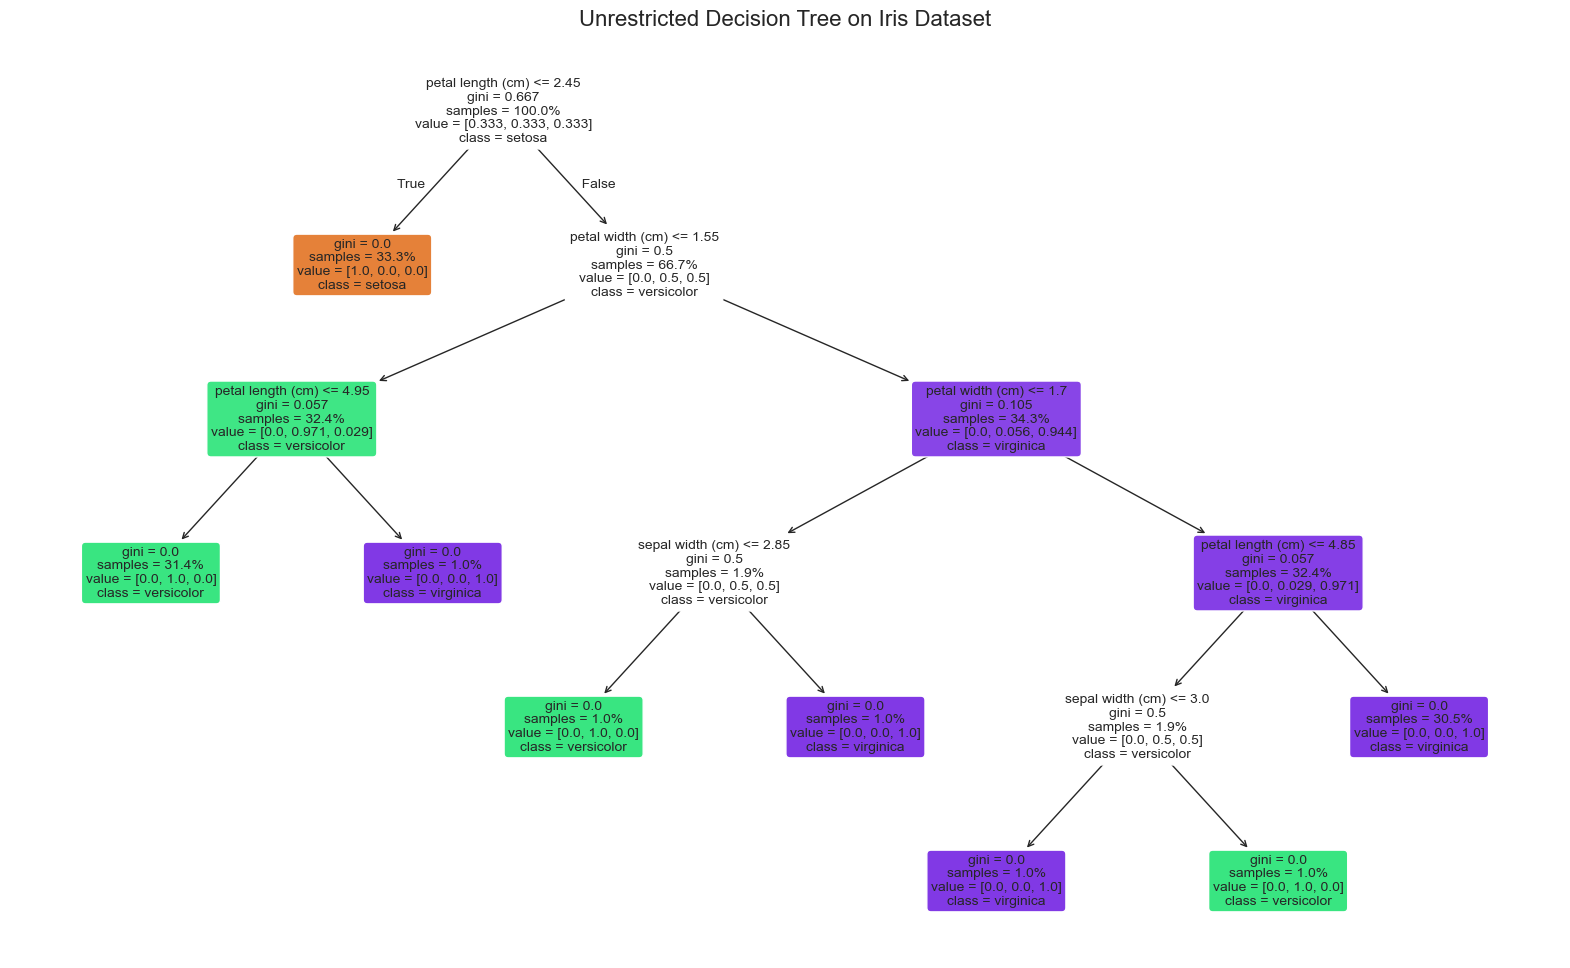

In [3]:
# Visual tree plot - the most intuitive way to understand splits
plt.figure(figsize=(20, 12))
plot_tree(
    dt_unrestricted,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,      # Color nodes by majority class
    rounded=True,     # Rounded corners for readability
    fontsize=10,
    proportion=True   # Show proportions instead of counts
)
plt.title("Unrestricted Decision Tree on Iris Dataset", fontsize=16)
plt.show()

In [4]:
# Text-based visualization - useful for quick inspection without graphics
tree_rules = export_text(
    dt_unrestricted,
    feature_names=feature_names,
    max_depth=3  # Limit depth for readability
)
print(tree_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: 1
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



In [5]:
# Programmatic access to tree structure via .tree_ attribute
tree = dt_unrestricted.tree_

print(f"Total nodes in tree: {tree.node_count}")
print(f"Number of features: {tree.n_features}")
print(f"Number of outputs (classes): {tree.n_outputs}")

# Inspect the root node (index 0)
print(f"\nRoot node statistics:")
print(f"  Feature used for split: {feature_names[tree.feature[0]]}")
print(f"  Threshold value: {tree.threshold[0]:.3f}")
print(f"  Impurity (Gini): {tree.impurity[0]:.4f}")
print(f"  Number of samples: {tree.n_node_samples[0]}")
print(f"  Value distribution: {tree.value[0]}")

Total nodes in tree: 15
Number of features: 4
Number of outputs (classes): 1

Root node statistics:
  Feature used for split: petal length (cm)
  Threshold value: 2.450
  Impurity (Gini): 0.6667
  Number of samples: 105
  Value distribution: [[0.33333333 0.33333333 0.33333333]]


**Understanding node statistics:**
- **samples**: Number of training samples reaching this node
- **value**: Array of sample counts per class `[setosa, versicolor, virginica]`
- **gini**: Impurity measure (0 = pure, 0.5 = maximum impurity for binary)
- **class**: Majority class at this node (determines prediction if leaf)

## 🧮 3. Understanding Split Criteria – Gini vs Entropy

The split criterion determines how we measure the "quality" of a split. Let's compare the two main options.

In [6]:
# Train two trees with different criteria
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

print("Comparison: Gini vs Entropy")
print("-" * 40)
print(f"{'Metric':<20} {'Gini':<15} {'Entropy':<15}")
print("-" * 40)
print(f"{'Depth':<20} {dt_gini.get_depth():<15} {dt_entropy.get_depth():<15}")
print(f"{'Leaves':<20} {dt_gini.get_n_leaves():<15} {dt_entropy.get_n_leaves():<15}")
print(f"{'Train Acc':<20} {accuracy_score(y_train, dt_gini.predict(X_train)):<15.4f} {accuracy_score(y_train, dt_entropy.predict(X_train)):<15.4f}")
print(f"{'Test Acc':<20} {accuracy_score(y_test, dt_gini.predict(X_test)):<15.4f} {accuracy_score(y_test, dt_entropy.predict(X_test)):<15.4f}")

Comparison: Gini vs Entropy
----------------------------------------
Metric               Gini            Entropy        
----------------------------------------
Depth                5               6              
Leaves               8               8              
Train Acc            1.0000          1.0000         
Test Acc             0.9333          0.8889         


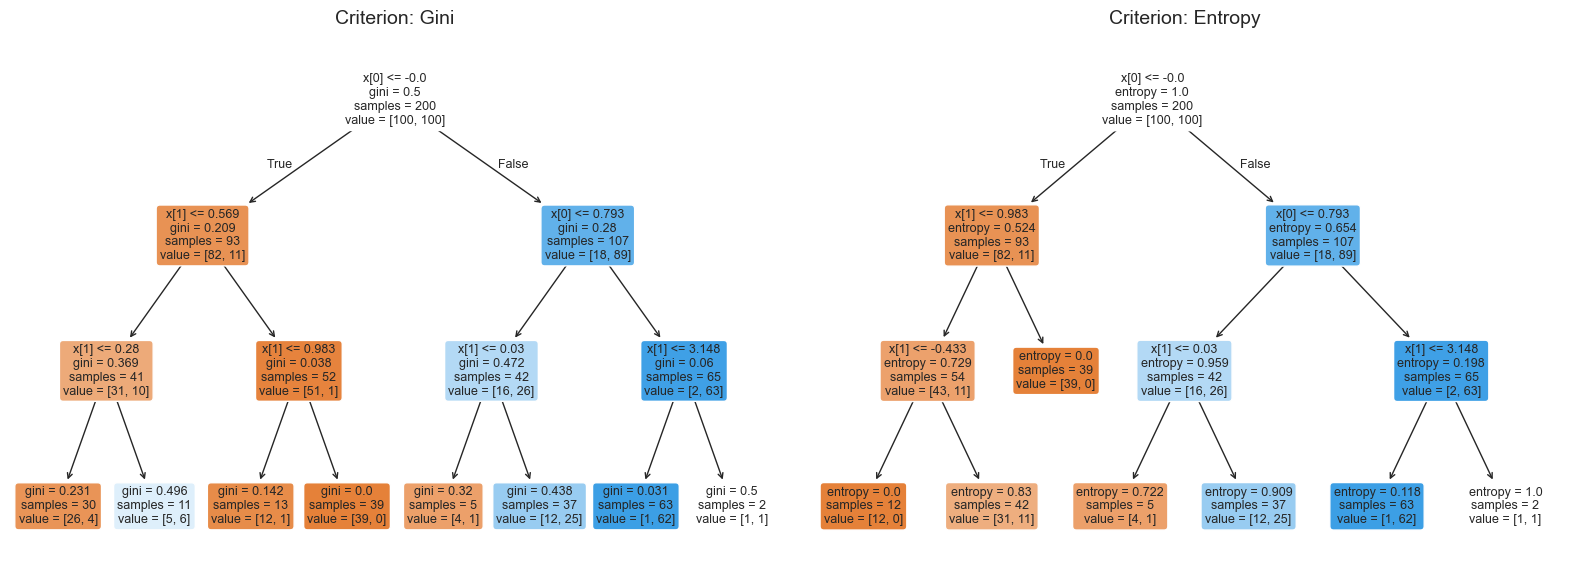

In [7]:
from sklearn.datasets import make_classification

# Create a simple 2D dataset for visualization
X_toy, y_toy = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42
)

# Train side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
criteria = ['gini', 'entropy']

for idx, criterion in enumerate(criteria):
    dt = DecisionTreeClassifier(criterion=criterion, max_depth=3, random_state=42)
    dt.fit(X_toy, y_toy)
    
    # Plot tree structure
    plot_tree(dt, filled=True, rounded=True, ax=axes[idx], fontsize=9)
    axes[idx].set_title(f"Criterion: {criterion.capitalize()}", fontsize=14)

plt.tight_layout()
plt.show()

**Mathematical Formulation:**

**Gini Impurity:** $Gini = 1 - \sum_{i=1}^{C} (p_i)^2$

**Entropy:** $Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$

Where $p_i$ is the proportion of class $i$ at the node.

**Key differences:**
- Gini is slightly faster to compute (no logarithms)
- Entropy penalizes impurity more heavily (tends to produce slightly more balanced trees)
- In practice, results are usually very similar

## 🌙 4. Demonstrating Overfitting – Moon-shaped Data

Now let's see overfitting in action with a deliberately noisy dataset where the true boundary is smooth but the tree creates jagged artifacts.

In [8]:
from sklearn.datasets import make_moons

# Create moon-shaped data with noise
X_moons, y_moons = make_moons(n_samples=300, noise=0.3, random_state=42)

# Split the data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train_m)}")
print(f"Test samples: {len(X_test_m)}")

Training samples: 210
Test samples: 90


In [9]:
# Train unrestricted tree - will overfit
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train_m, y_train_m)

# Train constrained tree - should generalize better
dt_constrained = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_constrained.fit(X_train_m, y_train_m)

print("Unrestricted Tree:")
print(f"  Depth: {dt_overfit.get_depth()}, Leaves: {dt_overfit.get_n_leaves()}")
print(f"  Train Acc: {accuracy_score(y_train_m, dt_overfit.predict(X_train_m)):.4f}")
print(f"  Test Acc: {accuracy_score(y_test_m, dt_overfit.predict(X_test_m)):.4f}")

print("\nConstrained Tree (max_depth=4):")
print(f"  Depth: {dt_constrained.get_depth()}, Leaves: {dt_constrained.get_n_leaves()}")
print(f"  Train Acc: {accuracy_score(y_train_m, dt_constrained.predict(X_train_m)):.4f}")
print(f"  Test Acc: {accuracy_score(y_test_m, dt_constrained.predict(X_test_m)):.4f}")

Unrestricted Tree:
  Depth: 11, Leaves: 31
  Train Acc: 1.0000
  Test Acc: 0.8556

Constrained Tree (max_depth=4):
  Depth: 4, Leaves: 11
  Train Acc: 0.9143
  Test Acc: 0.8667


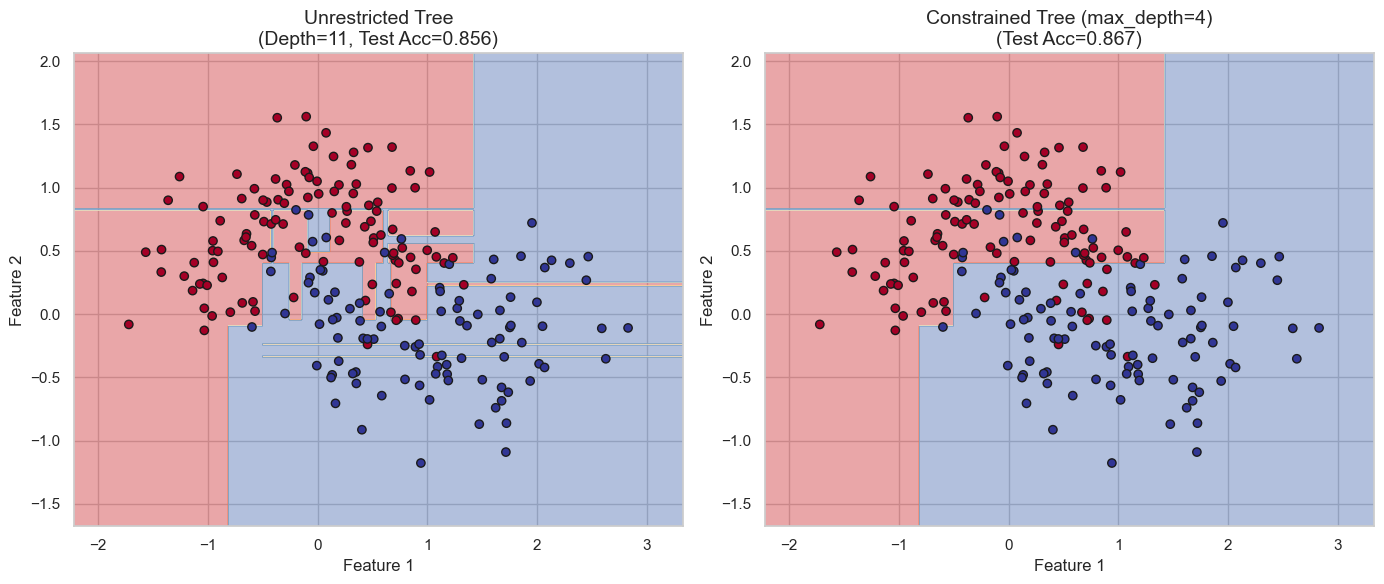

In [10]:
def plot_decision_boundary(X, y, model, title, ax):
    """Plot decision boundary for 2D data"""
    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return ax

# Visualize boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(X_train_m, y_train_m, dt_overfit, 
                       f"Unrestricted Tree\n(Depth={dt_overfit.get_depth()}, Test Acc={accuracy_score(y_test_m, dt_overfit.predict(X_test_m)):.3f})", 
                       axes[0])

plot_decision_boundary(X_train_m, y_train_m, dt_constrained,
                       f"Constrained Tree (max_depth=4)\n(Test Acc={accuracy_score(y_test_m, dt_constrained.predict(X_test_m)):.3f})",
                       axes[1])

plt.tight_layout()
plt.show()

**Observe the jagged boundary** on the left - that's overfitting. The tree is creating tiny pockets to capture individual noisy points. The constrained tree on the right sacrifices some training accuracy for a smoother, more generalizable boundary.

## ⚙️ 5. Key Hyperparameters for Controlling Complexity

Scikit-learn provides several ways to limit tree growth. Let's systematically compare them.

In [11]:
# Define parameter combinations to test
param_grid = [
    {'name': 'Default (unrestricted)', 'params': {}},
    {'name': 'max_depth=3', 'params': {'max_depth': 3}},
    {'name': 'max_depth=5', 'params': {'max_depth': 5}},
    {'name': 'min_samples_split=20', 'params': {'min_samples_split': 20}},
    {'name': 'min_samples_leaf=10', 'params': {'min_samples_leaf': 10}},
    {'name': 'max_leaf_nodes=8', 'params': {'max_leaf_nodes': 8}},
    {'name': 'Combined', 'params': {'max_depth': 5, 'min_samples_leaf': 5}},
]

results = []

for config in param_grid:
    dt = DecisionTreeClassifier(random_state=42, **config['params'])
    dt.fit(X_train_m, y_train_m)
    
    results.append({
        'Configuration': config['name'],
        'Depth': dt.get_depth(),
        'Leaves': dt.get_n_leaves(),
        'Train Acc': accuracy_score(y_train_m, dt.predict(X_train_m)),
        'Test Acc': accuracy_score(y_test_m, dt.predict(X_test_m)),
        'Gap': accuracy_score(y_train_m, dt.predict(X_train_m)) - accuracy_score(y_test_m, dt.predict(X_test_m))
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

         Configuration  Depth  Leaves  Train Acc  Test Acc       Gap
Default (unrestricted)     11      31   1.000000  0.855556  0.144444
           max_depth=3      3       7   0.895238  0.900000 -0.004762
           max_depth=5      5      14   0.919048  0.866667  0.052381
  min_samples_split=20      8      17   0.947619  0.888889  0.058730
   min_samples_leaf=10      6      13   0.909524  0.844444  0.065079
      max_leaf_nodes=8      6       8   0.928571  0.900000  0.028571
              Combined      5      14   0.933333  0.900000  0.033333


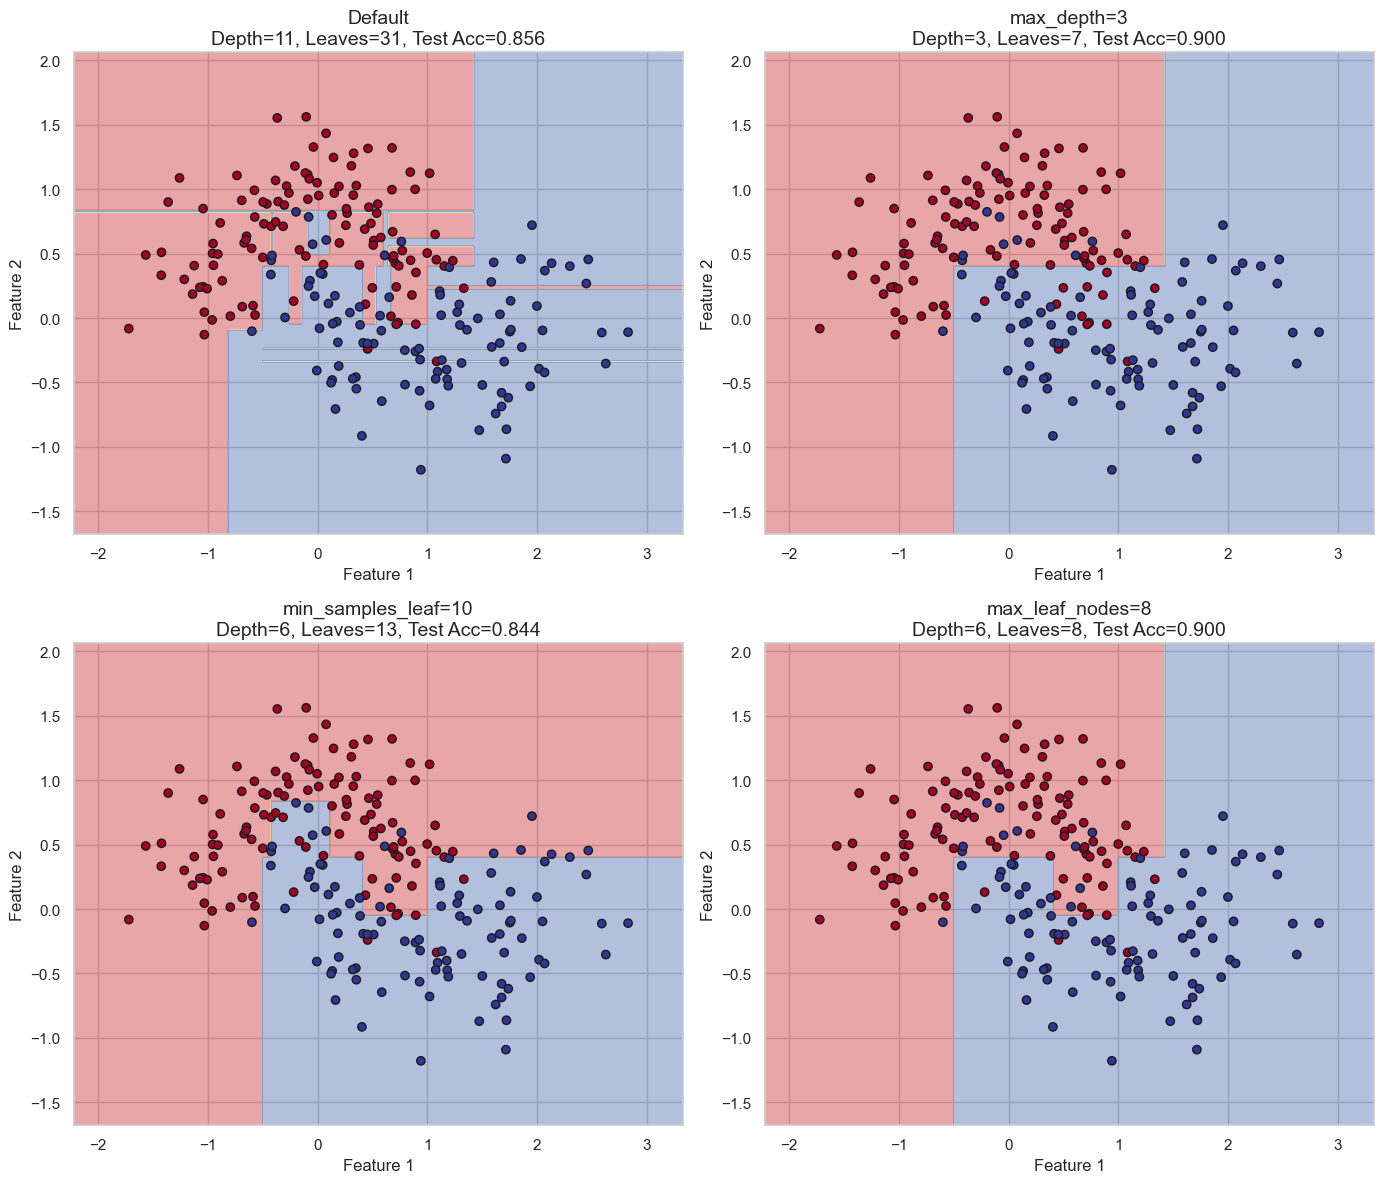

In [12]:
# Visualize boundaries for selected configurations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

selected_configs = [
    ('Default', {}),
    ('max_depth=3', {'max_depth': 3}),
    ('min_samples_leaf=10', {'min_samples_leaf': 10}),
    ('max_leaf_nodes=8', {'max_leaf_nodes': 8})
]

for idx, (name, params) in enumerate(selected_configs):
    dt = DecisionTreeClassifier(random_state=42, **params)
    dt.fit(X_train_m, y_train_m)
    test_acc = accuracy_score(y_test_m, dt.predict(X_test_m))
    
    plot_decision_boundary(X_train_m, y_train_m, dt, 
                          f"{name}\nDepth={dt.get_depth()}, Leaves={dt.get_n_leaves()}, Test Acc={test_acc:.3f}",
                          axes[idx])

plt.tight_layout()
plt.show()

**Parameter guide:**
- `max_depth`: Hard limit on tree depth (most intuitive)
- `min_samples_split`: Minimum samples required to split an internal node (prevents splitting small groups)
- `min_samples_leaf`: Minimum samples required at a leaf node (smooths boundaries)
- `max_leaf_nodes`: Maximum number of leaf nodes (alternative to depth control)

**Rule of thumb**: Start with `max_depth` and `min_samples_leaf` - they usually give the best control/performance tradeoff.

## ✂️ 6. Cost-Complexity Pruning (CCP – Post-pruning)

Pre-pruning (setting max_depth, etc.) requires guessing the right complexity beforehand. Post-pruning grows the full tree, then prunes back based on a complexity parameter. This is more principled.

In [13]:
# Get the pruning path
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_m, y_train_m)

# Extract cost complexity pruning path
path = dt_full.cost_complexity_pruning_path(X_train_m, y_train_m)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Number of effective alphas: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.6f}")
print(f"First few alphas: {ccp_alphas[:5]}")

Number of effective alphas: 14
Alpha range: 0.000000 to 0.189971
First few alphas: [0.         0.00438095 0.00442177 0.00444444 0.00446429]


In [ ]:
# Plot alpha vs total impurity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha vs impurity
ax1.plot(ccp_alphas, impurities, marker='o', markersize=3)
ax1.set_xlabel("Effective Alpha (ccp_alpha)")
ax1.set_ylabel("Total Impurity of Leaves")
ax1.set_title("Cost-Complexity Pruning Path")
ax1.set_xscale('log')

# Train trees with different alphas and count nodes
nodes_counts = []
train_scores = []
test_scores = []

for ccp_alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt_pruned.fit(X_train_m, y_train_m)
    nodes_counts.append(dt_pruned.tree_.node_count)
    train_scores.append(accuracy_score(y_train_m, dt_pruned.predict(X_train_m)))
    test_scores.append(accuracy_score(y_test_m, dt_pruned.predict(X_test_m)))

ax2.plot(ccp_alphas, nodes_counts, marker='o', markersize=3, label='Total Nodes')
ax2.set_xlabel("Effective Alpha (ccp_alpha)")
ax2.set_ylabel("Number of Nodes")
ax2.set_title("Tree Complexity vs Alpha")
ax2.set_xscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Find optimal alpha using cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = []
for ccp_alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    scores = cross_val_score(dt_pruned, X_train_m, y_train_m, cv=5)
    cv_scores.append(scores.mean())

# Find best alpha
best_alpha_idx = np.argmax(cv_scores)
best_alpha = ccp_alphas[best_alpha_idx]

print(f"Best alpha: {best_alpha:.6f}")
print(f"CV accuracy at best alpha: {cv_scores[best_alpha_idx]:.4f}")

# Plot CV scores
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, cv_scores, marker='o', markersize=3)
plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best alpha: {best_alpha:.6f}')
plt.xscale('log')
plt.xlabel('ccp_alpha')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Finding Optimal ccp_alpha via 5-Fold CV')
plt.legend()
plt.show()

In [ ]:
# Compare unpruned vs optimally pruned
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train_m, y_train_m)

dt_optimal = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
dt_optimal.fit(X_train_m, y_train_m)

print("Comparison: Unpruned vs Optimally Pruned")
print("-" * 50)
print(f"{'Metric':<25} {'Unpruned':<15} {'Pruned':<15}")
print("-" * 50)
print(f"{'Nodes':<25} {dt_unpruned.tree_.node_count:<15} {dt_optimal.tree_.node_count:<15}")
print(f"{'Depth':<25} {dt_unpruned.get_depth():<15} {dt_optimal.get_depth():<15}")
print(f"{'Leaves':<25} {dt_unpruned.get_n_leaves():<15} {dt_optimal.get_n_leaves():<15}")
print(f"{'Train Accuracy':<25} {accuracy_score(y_train_m, dt_unpruned.predict(X_train_m)):<15.4f} {accuracy_score(y_train_m, dt_optimal.predict(X_train_m)):<15.4f}")
print(f"{'Test Accuracy':<25} {accuracy_score(y_test_m, dt_unpruned.predict(X_test_m)):<15.4f} {accuracy_score(y_test_m, dt_optimal.predict(X_test_m)):<15.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(X_train_m, y_train_m, dt_unpruned, "Unpruned (Overfitting)", axes[0])
plot_decision_boundary(X_train_m, y_train_m, dt_optimal, f"CCP Pruned (alpha={best_alpha:.4f})", axes[1])
plt.show()

CCP pruning reduced the tree complexity while maintaining (or improving) test accuracy. This is the power of post-pruning: data-driven complexity selection.

## 📈 7. Regression Trees – Quick Example

Decision trees aren't just for classification. Let's see how they handle continuous targets.

In [17]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load diabetes dataset (regression)
diabetes = load_diabetes()
X_d, y_d = diabetes.data, diabetes.target

# Use only 2 features for visualization
X_d_vis = X_d[:, [2, 8]]  # BMI and s5 (log of serum triglycerides level)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d_vis, y_d, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train_d)}")
print(f"Features used: BMI and s5")

Training samples: 309
Features used: BMI and s5


In [18]:
# Train unrestricted and constrained regression trees
dt_reg_full = DecisionTreeRegressor(random_state=42)
dt_reg_constrained = DecisionTreeRegressor(max_depth=4, random_state=42)

dt_reg_full.fit(X_train_d, y_train_d)
dt_reg_constrained.fit(X_train_d, y_train_d)

# Predictions
y_pred_full = dt_reg_full.predict(X_test_d)
y_pred_constrained = dt_reg_constrained.predict(X_test_d)

print("Regression Tree Comparison:")
print(f"{'Metric':<25} {'Unrestricted':<15} {'max_depth=4':<15}")
print("-" * 55)
print(f"{'Depth':<25} {dt_reg_full.get_depth():<15} {dt_reg_constrained.get_depth():<15}")
print(f"{'Leaves':<25} {dt_reg_full.get_n_leaves():<15} {dt_reg_constrained.get_n_leaves():<15}")
print(f"{'Train R²':<25} {r2_score(y_train_d, dt_reg_full.predict(X_train_d)):<15.4f} {r2_score(y_train_d, dt_reg_constrained.predict(X_train_d)):<15.4f}")
print(f"{'Test R²':<25} {r2_score(y_test_d, y_pred_full):<15.4f} {r2_score(y_test_d, y_pred_constrained):<15.4f}")
print(f"{'Test RMSE':<25} {np.sqrt(mean_squared_error(y_test_d, y_pred_full)):<15.2f} {np.sqrt(mean_squared_error(y_test_d, y_pred_constrained)):<15.2f}")

Regression Tree Comparison:
Metric                    Unrestricted    max_depth=4    
-------------------------------------------------------
Depth                     17              4              
Leaves                    301             16             
Train R²                  0.9934          0.5649         
Test R²                   0.1147          0.3259         
Test RMSE                 69.13           60.32          


In [19]:
# Inspect tree structure for regression
tree_reg = dt_reg_constrained.tree_

print("First few splits of the constrained regression tree:")
for i in range(min(5, tree_reg.node_count)):
    if tree_reg.children_left[i] != tree_reg.children_right[i]:  # If not a leaf
        print(f"Node {i}: Split on feature {tree_reg.feature[i]} at threshold {tree_reg.threshold[i]:.3f}")
    else:
        print(f"Node {i}: Leaf with value {tree_reg.value[i][0][0]:.2f}")

First few splits of the constrained regression tree:
Node 0: Split on feature 0 at threshold 0.005
Node 1: Split on feature 1 at threshold 0.014
Node 2: Split on feature 1 at threshold -0.043
Node 3: Split on feature 0 at threshold -0.044
Node 4: Leaf with value 89.12


In [ ]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_regression_results(y_true, y_pred, title, ax):
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(title)
    ax.text(0.05, 0.95, f"R² = {r2_score(y_true, y_pred):.3f}\nRMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}",
            transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_regression_results(y_test_d, y_pred_full, "Unrestricted Tree (Overfitting)", axes[0])
plot_regression_results(y_test_d, y_pred_constrained, "Constrained Tree (max_depth=4)", axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# Residual plot
fig, ax = plt.subplots(figsize=(10, 6))
residuals_full = y_test_d - y_pred_full
residuals_constrained = y_test_d - y_pred_constrained

ax.scatter(y_pred_full, residuals_full, alpha=0.6, label='Unrestricted', edgecolors='k')
ax.scatter(y_pred_constrained, residuals_constrained, alpha=0.6, label='max_depth=4', edgecolors='k')
ax.axhline(y=0, color='r', linestyle='--')
ax.set_xlabel("Predicted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot: Unrestricted vs Constrained Regression Tree")
ax.legend()
plt.show()

**Key difference in regression trees:**
- Leaf nodes predict the **mean** of target values in that region
- Splits minimize **MSE** (or MAE) rather than Gini/entropy
- Same overfitting dangers apply - unrestricted trees create tiny regions for outliers

## ⚠️ Common Pitfalls & Pro Tips

- **Never use default trees in production**: `DecisionTreeClassifier()` without constraints will almost always overfit
- **Always set `random_state`**: Trees are deterministic given the same data, but feature ordering ties can cause instability across runs
- **`min_samples_leaf` is often better than `max_depth`**: It directly controls the smoothing of the decision boundary
- **Don't ignore small datasets**: With <100 samples, even `max_depth=3` might overfit
- **Pre-pruning vs Post-pruning**: Pre-pruning is faster (stops early), post-pruning is more accurate (finds optimal complexity)
- **Trees are NOT scale-invariant for monotonic transformations**: Log-transforming a feature changes where splits occur
- **Feature importance is biased**: Trees favor high-cardinality features; use permutation importance for reliable rankings
- **Instability is real**: Bootstrap your data and train 10 trees - you'll get 10 different structures. This is why we need Random Forests.
- **Don't one-hot encode for trees**: They handle categorical splits natively (though sklearn requires encoding - use `OrdinalEncoder` not `OneHotEncoder`)
- **Regression tree extrapolation**: Trees cannot predict outside the range of training data (they plateau)

## 📝 Exercises

### Easy
1. Train a `DecisionTreeClassifier` on the Wine dataset (`load_wine()`). Plot the tree with `max_depth=4` and identify which feature is used at the root node.

### Medium
2. Using `make_circles` (noisy circles dataset), compare decision boundaries between an unrestricted tree and one with `min_samples_leaf=5`. Visualize both boundaries side-by-side.

3. **Manual Gini Calculation**: Create a tiny 2D dataset with 6 points (3 class A, 3 class B). Calculate the Gini impurity manually for a split at x=0.5. Verify your calculation matches sklearn's output.

### Hard
4. Write a function `plot_tree_learning_curve(X, y, max_depth_range)` that:
   - Trains trees with increasing max_depth
   - Uses 5-fold CV to get validation scores
   - Plots training error and validation error vs depth
   - Returns the optimal depth

### Bonus
5. Apply Cost-Complexity Pruning on the Digits dataset (`load_digits()`):
   - Find the optimal `ccp_alpha` using cross-validation
   - Compare the number of leaves and accuracy between unpruned and optimally pruned trees
   - Visualize how accuracy changes with increasing alpha

<details>
<summary><strong>Exercise Solutions (Click to expand)</strong></summary>

### Exercise 1: Wine Dataset

```python
from sklearn.datasets import load_wine

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.3, stratify=y_wine, random_state=42
)

dt_wine = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_wine.fit(X_train_w, y_train_w)

plt.figure(figsize=(16, 8))
plot_tree(dt_wine, feature_names=wine.feature_names, class_names=wine.target_names, 
          filled=True, rounded=True, fontsize=10)
plt.show()

# Root feature
print(f"Root split feature: {wine.feature_names[dt_wine.tree_.feature[0]]}")
```

### Exercise 2: Make Circles

```python
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circ, y_circ, test_size=0.3, random_state=42
)

dt_circ1 = DecisionTreeClassifier(random_state=42)
dt_circ2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

dt_circ1.fit(X_train_c, y_train_c)
dt_circ2.fit(X_train_c, y_train_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(X_train_c, y_train_c, dt_circ1, "Unrestricted", axes[0])
plot_decision_boundary(X_train_c, y_train_c, dt_circ2, "min_samples_leaf=5", axes[1])
plt.show()
```

### Exercise 3: Manual Gini

```python
# Tiny dataset: 6 points
X_tiny = np.array([[0.1], [0.2], [0.4], [0.6], [0.8], [0.9]])
y_tiny = np.array([0, 0, 0, 1, 1, 1])  # 3 zeros, 3 ones

def gini_impurity(labels):
    if len(labels) == 0:
        return 0
    p = np.mean(labels)
    return 1 - (p**2 + (1-p)**2)

# Split at x=0.5
left_mask = X_tiny.ravel() <= 0.5
right_mask = ~left_mask

y_left, y_right = y_tiny[left_mask], y_tiny[right_mask]
n = len(y_tiny)

gini_left = gini_impurity(y_left)
gini_right = gini_impurity(y_right)
weighted_gini = (len(y_left)/n) * gini_left + (len(y_right)/n) * gini_right

print(f"Left group: {y_left}, Gini: {gini_left:.3f}")
print(f"Right group: {y_right}, Gini: {gini_right:.3f}")
print(f"Weighted Gini: {weighted_gini:.3f}")

# Verify with sklearn
dt_tiny = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_tiny.fit(X_tiny, y_tiny)
print(f"Sklearn root impurity: {dt_tiny.tree_.impurity[0]:.3f}")
```

### Exercise 4: Learning Curve Function

```python
from sklearn.model_selection import validation_curve

def plot_tree_learning_curve(X, y, max_depth_range=range(1, 20)):
    train_scores, val_scores = validation_curve(
        DecisionTreeClassifier(random_state=42), X, y,
        param_name='max_depth', param_range=max_depth_range,
        cv=5, scoring='accuracy'
    )
    
    train_mean = 1 - train_scores.mean(axis=1)  # Convert to error
    val_mean = 1 - val_scores.mean(axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(max_depth_range, train_mean, 'o-', label='Training Error')
    plt.plot(max_depth_range, val_mean, 'o-', label='Validation Error')
    plt.xlabel('max_depth')
    plt.ylabel('Error (1 - Accuracy)')
    plt.title('Decision Tree Learning Curve')
    plt.legend()
    plt.show()
    
    optimal_depth = list(max_depth_range)[np.argmin(val_mean)]
    return optimal_depth

# Usage
optimal = plot_tree_learning_curve(X_moons, y_moons)
print(f"Optimal depth: {optimal}")
```

### Exercise 5: CCP on Digits

```python
from sklearn.datasets import load_digits

digits = load_digits()
X_dig, y_dig = digits.data, digits.target
X_train_dig, X_test_dig, y_train_dig, y_test_dig = train_test_split(
    X_dig, y_dig, test_size=0.3, random_state=42
)

# Get pruning path
dt_dig = DecisionTreeClassifier(random_state=42)
dt_dig.fit(X_train_dig, y_train_dig)
path_dig = dt_dig.cost_complexity_pruning_path(X_train_dig, y_train_dig)

# Find optimal alpha
alphas_dig = path_dig.ccp_alphas[::10]  # Subsample for speed
cv_scores_dig = []

for alpha in alphas_dig:
    dt_alpha = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(dt_alpha, X_train_dig, y_train_dig, cv=3)
    cv_scores_dig.append(scores.mean())

best_alpha_dig = alphas_dig[np.argmax(cv_scores_dig)]

# Compare
dt_unpruned_dig = DecisionTreeClassifier(random_state=42).fit(X_train_dig, y_train_dig)
dt_pruned_dig = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha_dig).fit(X_train_dig, y_train_dig)

print(f"Unpruned: {dt_unpruned_dig.get_n_leaves()} leaves, "
      f"Test acc: {accuracy_score(y_test_dig, dt_unpruned_dig.predict(X_test_dig)):.4f}")
print(f"Pruned: {dt_pruned_dig.get_n_leaves()} leaves, "
      f"Test acc: {accuracy_score(y_test_dig, dt_pruned_dig.predict(X_test_dig)):.4f}")
```

</details>

## Summary – What You Learned Today

- **Impurity criteria**: Gini and entropy both measure split quality; Gini is faster, entropy is more theoretically grounded
- **Tree internals**: The `.tree_` attribute exposes the complete tree structure - nodes, thresholds, impurity, samples
- **Visualization**: `plot_tree()` reveals the decision logic; decision boundary plots reveal overfitting geometrically
- **Overfitting mechanics**: Unrestricted trees create axis-aligned jagged boundaries to memorize noise
- **Pre-pruning**: `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes` control complexity before growing
- **Post-pruning**: CCP (`ccp_alpha`) finds the optimal subtree by trading off complexity vs. impurity reduction
- **Regression differences**: Trees predict means in leaf nodes and minimize MSE/MAE instead of Gini
- **Instability**: Trees are high-variance estimators - small data changes create completely different trees

---